# Notebook to plot River Discharge during Floods
- Jeamilett Martinez, Kristina Black, Alice DuVivier
- April 2026

## Import the python modules we'll need

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
import numpy as np
import glob
import xarray as xr
import os
from scipy.stats import ttest_1samp
import geopandas as gpd
import matplotlib.cm as cm
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize, to_rgba
from matplotlib.collections import LineCollection
from cartopy.feature import ShapelyFeature
from cartopy import crs as ccrs
from shapely.geometry import LineString, MultiLineString, Point
from matplotlib.cm import ScalarMappable

# Load Historical River discharge data

In [2]:
# set input directory
dir_in = '/glade/u/home/duvivier/projects/arctic_actionable/soars/yukon_river_2025/yukon_flooding/other_files/'

In [3]:
# Starting with historical ensemble
file_list = glob.glob(dir_in+'*historical_Q.nc')

## 2009 - Flood in Eagle

### Find grid point closest to village

In [4]:
# Coordinates for village
lat_village = 64.786022 
lon_village = -141.199917
village_name = 'Eagle'
comid = 81014736
yy = 2009

In [5]:
# Create a GeoDataFrame
village = gpd.GeoDataFrame({'name': [village_name]},
                           geometry=[Point(lon_village, lat_village)],
                           crs="EPSG:4326")  # geographic lat/lon

In [6]:
# Load ice breakup data
df = pd.read_csv(dir_in+'Phenology.csv')
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
# Extract Village breakup dates
village_breakup = df[(df['Event'] == 'breakup') & (df['COMID'] == comid)].copy()
village_breakup = village_breakup.set_index('Year')

In [8]:
# breakup dates
village_breakup['Date'] = pd.to_datetime(village_breakup['Date'])

# Segment for village
target_seg = comid

### Plot river flow AT VILLAGE around breakup dates

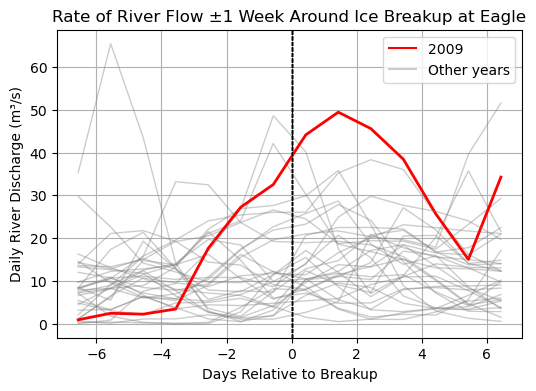

In [9]:
# Initialize plot
plt.figure(figsize=(6, 4))

for file in file_list:
    try:
        # Extract year from filename like "2021_historical_Q.nc"
        year_str = os.path.basename(file).split("_")[0]
        year = int(year_str)
        
        # Skip if year not in breakup data
        if year not in village_breakup.index:
            continue

        # Load file and extract flow for village
        ds = xr.open_dataset(file)
        flow = ds['IRFroutedRunoff'].sel(seg=target_seg)

        # Get breakup date
        breakup_date = village_breakup.loc[year, 'Date']
        start = breakup_date - pd.Timedelta(days=7)
        end = breakup_date + pd.Timedelta(days=7)

        # Subset and sort
        flow_window = flow.sel(time=slice(start, end)).sortby('time')
        if flow_window.size < 10:
            continue

        # Relative days
        relative_days = (flow_window.time.values - np.datetime64(breakup_date)) / np.timedelta64(1, 'D')

        # Plot style
        color = 'red' if year == yy else 'gray'
        lw = 2 if year == yy else 1
        alpha = 1.0 if year == yy else 0.4
        label = str(year) if year == yy else None
        plt.grid(True)
        plt.axvline(x=0, linestyle='--', color='black', linewidth=0.75)
        plt.title('Rate of River Flow ±1 Week Around Ice Breakup at '+village_name)
        plt.xlabel('Days Relative to Breakup')
        plt.ylabel('Daily River Discharge (m³/s)')
        plt.plot(relative_days, flow_window.values, color=color, linewidth=lw, alpha=alpha, label=label)

    except Exception as e:
        print(f"Skipping file {file} due to error: {e}")

red_line = mlines.Line2D([], [], color='red', label=str(yy))
gray_line = mlines.Line2D([], [], color='gray', alpha=0.4, label='Other years')

plt.legend(handles=[red_line, gray_line])
#plt.savefig("SOARS_river_flow_line_2009.pdf", format='pdf', bbox_inches='tight')
plt.show()

Flood year Rate of Change: 16.91
Mean of other years: 1.66
T-statistic: -8.58, p-value: 1.42e-09


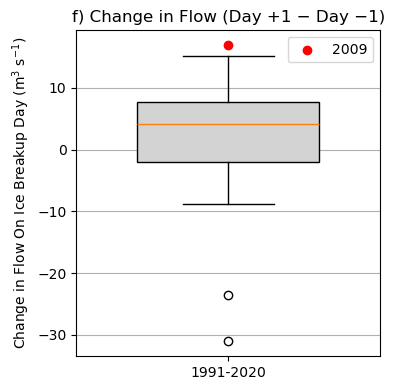

In [10]:
# Store rate-of-change values and Plot distribution
roc_dict = {}

fout = 'river_flow_anomaly_on_breakup_'+village_name+'_'+str(yy)+'.png'

for file in file_list:
    try:
        year = int(os.path.basename(file).split("_")[0])
        if year not in village_breakup.index:
            continue

        ds = xr.open_dataset(file)
        flow = ds['IRFroutedRunoff'].sel(seg=target_seg)

        breakup_date = village_breakup.loc[year, 'Date']
        day_minus_1 = breakup_date - pd.Timedelta(days=1)
        day_plus_1 = breakup_date + pd.Timedelta(days=1)

        # Get flow at -1 and +1 days
        flow_minus_1 = flow.sel(time=day_minus_1, method='nearest').values.item()
        flow_plus_1 = flow.sel(time=day_plus_1, method='nearest').values.item()

        roc = flow_plus_1 - flow_minus_1
        roc_dict[year] = roc

    except Exception as e:
        print(f"Skipping {file}: {e}")

# Convert to DataFrame
roc_df = pd.DataFrame.from_dict(roc_dict, orient='index', columns=['RateOfChange'])
roc_df.index.name = 'Year'
roc_df.reset_index(inplace=True)

# Separate flood year and others
roc_yyyy = roc_df.loc[roc_df['Year'] == yy, 'RateOfChange'].values[0]
roc_others = roc_df.loc[roc_df['Year'] != yy, 'RateOfChange'].values

# Perform one-sample t-test
t_stat, p_value = ttest_1samp(roc_others, roc_yyyy)

print(f"Flood year Rate of Change: {roc_yyyy:.2f}")
print(f"Mean of other years: {np.mean(roc_others):.2f}")
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.2e}")

# Plot
plt.figure(figsize=(4, 4))
plt.boxplot(roc_others, positions=[0], widths=0.6, patch_artist=True, boxprops=dict(facecolor='lightgray'))
plt.scatter([0], [roc_yyyy], color='red', label=str(yy), zorder=10)
plt.ylabel(r'Change in Flow On Ice Breakup Day (m$^3$ s$^{-1}$)')
plt.title('f) Change in Flow (Day +1 − Day −1)')
plt.xticks([0], ['1991-2020'])
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
plt.savefig(fout, format='pdf', bbox_inches='tight')
plt.show()


### Plot map of river flow around breakup date

In [11]:
# set shapefile directory
shp_dir_in = '/glade/u/home/duvivier/projects/arctic_actionable/soars/yukon_river_2025/yukon_flooding/shapefiles/'

In [12]:
# Load Alaska and Canadian provinces
states = gpd.read_file(shp_dir_in+'ne_50m_admin_1_states_provinces.shp')

region = states[states['name'].isin(['Alaska', 'Yukon', 'Northwest Territories', 'British Columbia'])]

# Data source: Natural Earth, States and Provinces (downloaded from https://www.naturalearthdata.com/downloads/50m-cultural-vectors/)

In [13]:
# Load river basin shapefile for the Arctic
hb = gpd.read_file(shp_dir_in+'hybas_ar_lev03_v1c.shp')
print(hb.columns)

# Rough bounding box for Yukon River Basin (in degrees)
yukon = hb[hb['PFAF_ID'] == 812]
yukon = yukon.to_crs("EPSG:4326")

# Reproject to match the map projection
#boundary_proj = yukon.to_crs(ccrs.NorthPolarStereo(central_longitude=-150.0).proj4_init)

Index(['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK',
       'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER',
       'SORT', 'geometry'],
      dtype='object')


In [14]:
# Load river vector data from GPKG
gpkg_path = dir_in+'AK_Rivers.gpkg'
layer_name = "AK_Rivers"

gdf = gpd.read_file(gpkg_path, layer=layer_name)

# View column names to find the segment ID
print(gdf.columns)


Index(['COMID', 'lengthkm', 'lengthdir', 'sinuosity', 'slope', 'uparea',
       'order', 'strmDrop_t', 'slope_taud', 'NextDownID', 'maxup', 'up1',
       'up2', 'up3', 'up4', 'geometry'],
      dtype='object')


In [15]:
# Define helper to compute April–May mean
def get_april_may_mean(file_path, var_name='IRFroutedRunoff'):
    ds = xr.open_dataset(file_path)
    flow = ds[var_name]

    # Ensure time is datetime
    if not np.issubdtype(flow['time'].dtype, np.datetime64):
        flow['time'] = pd.to_datetime(flow['time'].values)

    # Filter for April and May
    april_may = flow.sel(time=flow['time.month'].isin([4, 5]))
    
    return april_may.mean(dim='time')

In [16]:
# Calculate flow anomalies for flood year

file_yyyy = dir_in+str(yy)+'_historical_Q.nc'

historical_files = sorted(glob.glob(dir_in+'*historical_Q.nc'))
historical_files = [f for f in historical_files if 1995 <= int(os.path.basename(f).split("_")[0]) <= 2005]

# ---- Load and clean flood year flow (April–May only) ----
flow_yyyy = get_april_may_mean(file_yyyy)
flow_yyyy_df = flow_yyyy.to_dataframe(name='flow_'+str(yy)).reset_index()
flow_yyyy_df = flow_yyyy_df.drop_duplicates(subset='seg')

# ---- Load and stack historical flows ----
hist_flows = []
for f in historical_files:
    try:
        flow_mean = get_april_may_mean(f)
        df = flow_mean.to_dataframe(name='IRFroutedRunoff').reset_index()
        df = df.drop_duplicates(subset='seg')
        xarr = df.set_index('seg').to_xarray()
        hist_flows.append(xarr)
    except Exception as e:
        print(f"Skipping {f}: {e}")
        

# Stack and compute historical mean
stacked = xr.concat(hist_flows, dim='year')
mean_hist = stacked.mean(dim='year')
mean_hist_df = mean_hist.to_dataframe().reset_index()
mean_hist_df = mean_hist_df.rename(columns={'IRFroutedRunoff': 'mean_hist'})
mean_hist_df = mean_hist_df.drop_duplicates(subset='seg')

# ---- Merge and calculate anomaly ----
merged_df = pd.merge(flow_yyyy_df, mean_hist_df, on='seg', how='inner')
merged_df['anomaly'] = merged_df['flow_'+str(yy)] - merged_df['mean_hist']
merged_df = merged_df.rename(columns={'seg': 'COMID'})

In [17]:
gdf_merged = gdf.merge(merged_df[['COMID', 'anomaly']], on='COMID')
gdf_merged['linewidth'] = gdf_merged['anomaly'].abs() / gdf_merged['anomaly'].abs().max() * 3.5 + 0.5

# Optional: Check min/max before plotting
print("Min:", gdf_merged['anomaly'].min())
print("Max:", gdf_merged['anomaly'].max())


if village.crs != gdf_merged.crs:
    village = village.to_crs(gdf_merged.crs)

Min: -106.77238464355469
Max: 1869.2138671875


In [18]:
# Normalize color scale
vmin = 0
vmax = 2000
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("plasma")

# Normalize alpha based on abs(anomaly)
abs_anomaly = gdf_merged['anomaly'].abs()
alpha_norm = (abs_anomaly - abs_anomaly.min()) / (abs_anomaly.max() - abs_anomaly.min())
gdf_merged['alpha'] = alpha_norm * 0.8 + 0.2  # scale from 0.2 to 1.0

# Normalize linewidth
gdf_merged['linewidth'] = abs_anomaly / abs_anomaly.max() * 3.5 + 0.5

In [19]:
# Build segments, colors, widths, alpha from gdf_merged
segments = []
colors = []
widths = []

for _, row in gdf_merged.iterrows():
    geom = row.geometry
    if geom is None:
        continue
    if geom.geom_type == 'LineString':
        coords = np.array(geom.coords)
        segments.append(coords)
        rgba = to_rgba(cmap(norm(row['anomaly'])), alpha=row['alpha'])
        colors.append(rgba)
        widths.append(row['linewidth'])
    elif geom.geom_type == 'MultiLineString':
        for part in geom:
            coords = np.array(part.coords)
            segments.append(coords)
            rgba = to_rgba(cmap(norm(row['anomaly'])), alpha=row['alpha'])
            colors.append(rgba)
            widths.append(row['linewidth'])

# Create a *fresh* LineCollection
lc = LineCollection(segments, colors=colors, linewidths=widths, zorder=1)

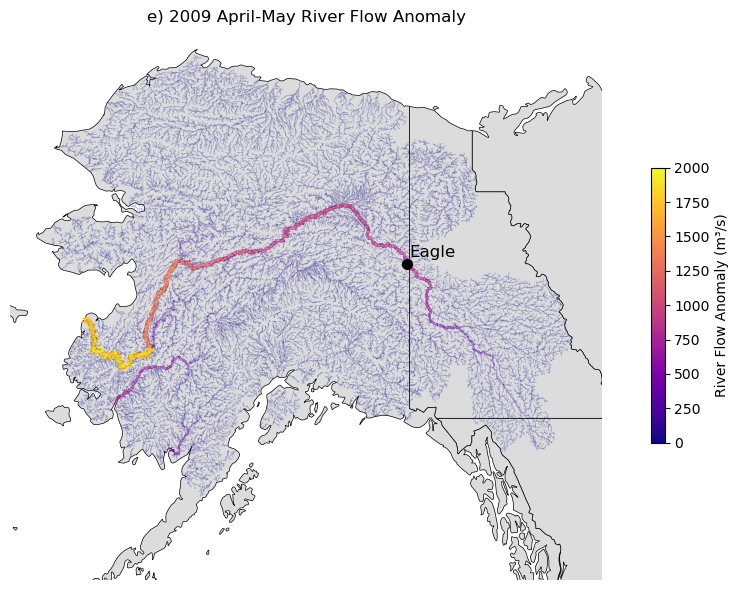

In [20]:
# plot map of anomalous streamflow

fout = 'river_flow_map_'+str(yy)+'.png'
fig = plt.figure(figsize=(10,6))

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

region.plot(ax=ax, color='gainsboro', edgecolor='black', linewidth=0.5, zorder=0)
ax.add_collection(lc)

# Add village point + label
village.plot(ax=ax, color='black', marker='o', markersize=50, zorder=2)
for x, y, label in zip(village.geometry.x, village.geometry.y, village['name']):
    ax.text(x + 0.2, y + 0.2, label, fontsize=12, color='black')

# Colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.5).set_label("River Flow Anomaly (m³/s)")

ax.set_xlim(-170, -127)
ax.set_ylim(55, 72)
ax.set_title('e) '+str(yy)+' April-May River Flow Anomaly')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(fout, format='pdf', bbox_inches='tight')
plt.show()


## 2013 - Flood in Galena

### Find grid point closest to village

In [21]:
# Coordinates for village
lat_village = 64.740643 
lon_village = -156.885462
village_name = 'Galena'
comid = 81014218
yy = 2013

In [22]:
# Create a GeoDataFrame
village = gpd.GeoDataFrame({'name': [village_name]},
                           geometry=[Point(lon_village, lat_village)],
                           crs="EPSG:4326")  # geographic lat/lon

In [23]:
# Load ice breakup data
df = pd.read_csv(dir_in+'Phenology.csv')
df['Date'] = pd.to_datetime(df['Date'])

In [24]:
# Extract Village breakup dates
village_breakup = df[(df['Event'] == 'breakup') & (df['COMID'] == comid)].copy()
village_breakup = village_breakup.set_index('Year')


In [25]:
# breakup dates
village_breakup['Date'] = pd.to_datetime(village_breakup['Date'])

# Segment for village
target_seg = comid

### Plot river flow AT VILLAGE around breakup dates

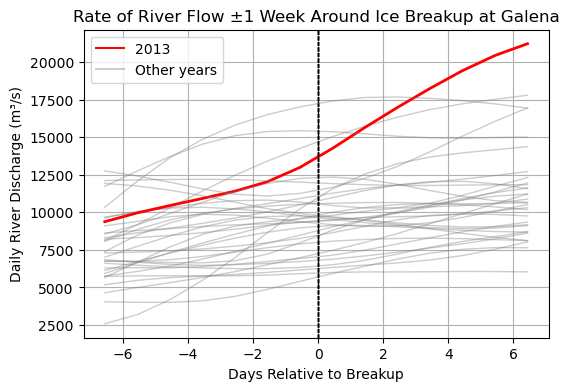

In [26]:
# Initialize plot
plt.figure(figsize=(6, 4))

for file in file_list:
    try:
        # Extract year from filename like "2021_historical_Q.nc"
        year_str = os.path.basename(file).split("_")[0]
        year = int(year_str)
        
        # Skip if year not in breakup data
        if year not in village_breakup.index:
            continue

        # Load file and extract flow for village
        ds = xr.open_dataset(file)
        flow = ds['IRFroutedRunoff'].sel(seg=target_seg)

        # Get breakup date
        breakup_date = village_breakup.loc[year, 'Date']
        start = breakup_date - pd.Timedelta(days=7)
        end = breakup_date + pd.Timedelta(days=7)

        # Subset and sort
        flow_window = flow.sel(time=slice(start, end)).sortby('time')
        if flow_window.size < 10:
            continue

        # Relative days
        relative_days = (flow_window.time.values - np.datetime64(breakup_date)) / np.timedelta64(1, 'D')

        # Plot style
        color = 'red' if year == yy else 'gray'
        lw = 2 if year == yy else 1
        alpha = 1.0 if year == yy else 0.4
        label = str(year) if year == yy else None
        plt.grid(True)
        plt.axvline(x=0, linestyle='--', color='black', linewidth=0.75)
        plt.title('Rate of River Flow ±1 Week Around Ice Breakup at '+village_name)
        plt.xlabel('Days Relative to Breakup')
        plt.ylabel('Daily River Discharge (m³/s)')
        plt.plot(relative_days, flow_window.values, color=color, linewidth=lw, alpha=alpha, label=label)

    except Exception as e:
        print(f"Skipping file {file} due to error: {e}")

red_line = mlines.Line2D([], [], color='red', label=str(yy))
gray_line = mlines.Line2D([], [], color='gray', alpha=0.4, label='Other years')

plt.legend(handles=[red_line, gray_line])
#plt.savefig("SOARS_river_flow_line_2009.pdf", format='pdf', bbox_inches='tight')
plt.show()

Flood year Rate of Change: 2661.16
Mean of other years: 462.90
T-statistic: -18.95, p-value: 3.04e-18


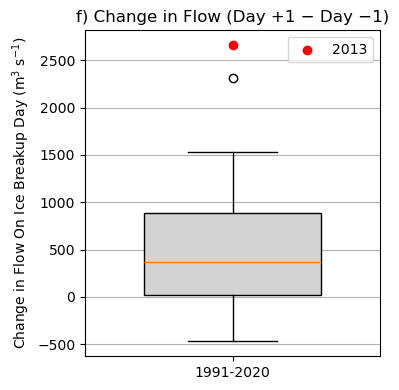

In [27]:
# Store rate-of-change values and Plot distribution
roc_dict = {}

fout = 'river_flow_anomaly_on_breakup_'+village_name+'_'+str(yy)+'.png'

for file in file_list:
    try:
        year = int(os.path.basename(file).split("_")[0])
        if year not in village_breakup.index:
            continue

        ds = xr.open_dataset(file)
        flow = ds['IRFroutedRunoff'].sel(seg=target_seg)

        breakup_date = village_breakup.loc[year, 'Date']
        day_minus_1 = breakup_date - pd.Timedelta(days=1)
        day_plus_1 = breakup_date + pd.Timedelta(days=1)

        # Get flow at -1 and +1 days
        flow_minus_1 = flow.sel(time=day_minus_1, method='nearest').values.item()
        flow_plus_1 = flow.sel(time=day_plus_1, method='nearest').values.item()

        roc = flow_plus_1 - flow_minus_1
        roc_dict[year] = roc

    except Exception as e:
        print(f"Skipping {file}: {e}")

# Convert to DataFrame
roc_df = pd.DataFrame.from_dict(roc_dict, orient='index', columns=['RateOfChange'])
roc_df.index.name = 'Year'
roc_df.reset_index(inplace=True)

# Separate flood year and others
roc_yyyy = roc_df.loc[roc_df['Year'] == yy, 'RateOfChange'].values[0]
roc_others = roc_df.loc[roc_df['Year'] != yy, 'RateOfChange'].values

# Perform one-sample t-test
t_stat, p_value = ttest_1samp(roc_others, roc_yyyy)

print(f"Flood year Rate of Change: {roc_yyyy:.2f}")
print(f"Mean of other years: {np.mean(roc_others):.2f}")
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.2e}")

# Plot
plt.figure(figsize=(4, 4))
plt.boxplot(roc_others, positions=[0], widths=0.6, patch_artist=True, boxprops=dict(facecolor='lightgray'))
plt.scatter([0], [roc_yyyy], color='red', label=str(yy), zorder=10)
plt.ylabel(r'Change in Flow On Ice Breakup Day (m$^3$ s$^{-1}$)')
plt.title('f) Change in Flow (Day +1 − Day −1)')
plt.xticks([0], ['1991-2020'])
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
plt.savefig(fout, format='pdf', bbox_inches='tight')
plt.show()


### Plot map of river flow around breakup date

In [28]:
# set shapefile directory
shp_dir_in = '/glade/u/home/duvivier/projects/arctic_actionable/soars/yukon_river_2025/yukon_flooding/shapefiles/'

In [29]:
# Load Alaska and Canadian provinces
states = gpd.read_file(shp_dir_in+'ne_50m_admin_1_states_provinces.shp')

region = states[states['name'].isin(['Alaska', 'Yukon', 'Northwest Territories', 'British Columbia'])]

# Data source: Natural Earth, States and Provinces (downloaded from https://www.naturalearthdata.com/downloads/50m-cultural-vectors/)

In [30]:
# Load river basin shapefile for the Arctic
hb = gpd.read_file(shp_dir_in+'hybas_ar_lev03_v1c.shp')
print(hb.columns)

# Rough bounding box for Yukon River Basin (in degrees)
yukon = hb[hb['PFAF_ID'] == 812]
yukon = yukon.to_crs("EPSG:4326")

# Reproject to match the map projection
#boundary_proj = yukon.to_crs(ccrs.NorthPolarStereo(central_longitude=-150.0).proj4_init)

Index(['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK',
       'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER',
       'SORT', 'geometry'],
      dtype='object')


In [31]:
# Load river vector data from GPKG
gpkg_path = dir_in+'AK_Rivers.gpkg'
layer_name = "AK_Rivers"

gdf = gpd.read_file(gpkg_path, layer=layer_name)

# View column names to find the segment ID
print(gdf.columns)


Index(['COMID', 'lengthkm', 'lengthdir', 'sinuosity', 'slope', 'uparea',
       'order', 'strmDrop_t', 'slope_taud', 'NextDownID', 'maxup', 'up1',
       'up2', 'up3', 'up4', 'geometry'],
      dtype='object')


In [32]:
# Define helper to compute April–May mean
def get_april_may_mean(file_path, var_name='IRFroutedRunoff'):
    ds = xr.open_dataset(file_path)
    flow = ds[var_name]

    # Ensure time is datetime
    if not np.issubdtype(flow['time'].dtype, np.datetime64):
        flow['time'] = pd.to_datetime(flow['time'].values)

    # Filter for April and May
    april_may = flow.sel(time=flow['time.month'].isin([4, 5]))
    
    return april_may.mean(dim='time')

In [33]:
# Calculate flow anomalies for flood year

file_yyyy = dir_in+str(yy)+'_historical_Q.nc'

historical_files = sorted(glob.glob(dir_in+'*historical_Q.nc'))
historical_files = [f for f in historical_files if 1995 <= int(os.path.basename(f).split("_")[0]) <= 2005]

# ---- Load and clean flood year flow (April–May only) ----
flow_yyyy = get_april_may_mean(file_yyyy)
flow_yyyy_df = flow_yyyy.to_dataframe(name='flow_'+str(yy)).reset_index()
flow_yyyy_df = flow_yyyy_df.drop_duplicates(subset='seg')

# ---- Load and stack historical flows ----
hist_flows = []
for f in historical_files:
    try:
        flow_mean = get_april_may_mean(f)
        df = flow_mean.to_dataframe(name='IRFroutedRunoff').reset_index()
        df = df.drop_duplicates(subset='seg')
        xarr = df.set_index('seg').to_xarray()
        hist_flows.append(xarr)
    except Exception as e:
        print(f"Skipping {f}: {e}")
        

# Stack and compute historical mean
stacked = xr.concat(hist_flows, dim='year')
mean_hist = stacked.mean(dim='year')
mean_hist_df = mean_hist.to_dataframe().reset_index()
mean_hist_df = mean_hist_df.rename(columns={'IRFroutedRunoff': 'mean_hist'})
mean_hist_df = mean_hist_df.drop_duplicates(subset='seg')

# ---- Merge and calculate anomaly ----
merged_df = pd.merge(flow_yyyy_df, mean_hist_df, on='seg', how='inner')
merged_df['anomaly'] = merged_df['flow_'+str(yy)] - merged_df['mean_hist']
merged_df = merged_df.rename(columns={'seg': 'COMID'})

In [34]:
gdf_merged = gdf.merge(merged_df[['COMID', 'anomaly']], on='COMID')
gdf_merged['linewidth'] = gdf_merged['anomaly'].abs() / gdf_merged['anomaly'].abs().max() * 3.5 + 0.5

# Optional: Check min/max before plotting
print("Min:", gdf_merged['anomaly'].min())
print("Max:", gdf_merged['anomaly'].max())


if village.crs != gdf_merged.crs:
    village = village.to_crs(gdf_merged.crs)

Min: -4507.33984375
Max: 591.726806640625


In [35]:
# Normalize color scale
vmin = 0
vmax = 1000
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("plasma")

# Normalize alpha based on abs(anomaly)
abs_anomaly = gdf_merged['anomaly'].abs()
alpha_norm = (abs_anomaly - abs_anomaly.min()) / (abs_anomaly.max() - abs_anomaly.min())
gdf_merged['alpha'] = alpha_norm * 0.8 + 0.2  # scale from 0.2 to 1.0

# Normalize linewidth
gdf_merged['linewidth'] = abs_anomaly / abs_anomaly.max() * 3.5 + 0.5

In [36]:
# Build segments, colors, widths, alpha from gdf_merged
segments = []
colors = []
widths = []

for _, row in gdf_merged.iterrows():
    geom = row.geometry
    if geom is None:
        continue
    if geom.geom_type == 'LineString':
        coords = np.array(geom.coords)
        segments.append(coords)
        rgba = to_rgba(cmap(norm(row['anomaly'])), alpha=row['alpha'])
        colors.append(rgba)
        widths.append(row['linewidth'])
    elif geom.geom_type == 'MultiLineString':
        for part in geom:
            coords = np.array(part.coords)
            segments.append(coords)
            rgba = to_rgba(cmap(norm(row['anomaly'])), alpha=row['alpha'])
            colors.append(rgba)
            widths.append(row['linewidth'])

# Create a *fresh* LineCollection
lc = LineCollection(segments, colors=colors, linewidths=widths, zorder=1)

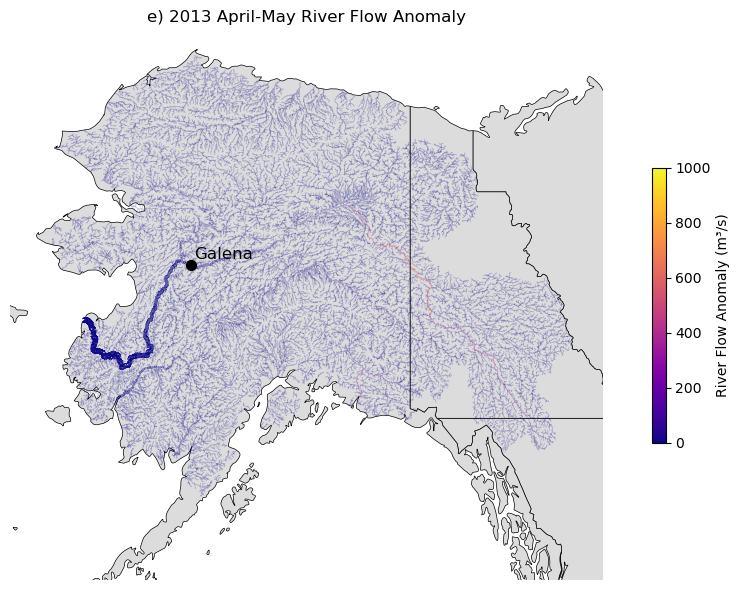

In [37]:
# plot map of anomalous streamflow

fout = 'river_flow_map_'+str(yy)+'.png'
fig = plt.figure(figsize=(10,6))

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

region.plot(ax=ax, color='gainsboro', edgecolor='black', linewidth=0.5, zorder=0)
ax.add_collection(lc)

# Add village point + label
village.plot(ax=ax, color='black', marker='o', markersize=50, zorder=2)
for x, y, label in zip(village.geometry.x, village.geometry.y, village['name']):
    ax.text(x + 0.2, y + 0.2, label, fontsize=12, color='black')

# Colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.5).set_label("River Flow Anomaly (m³/s)")

ax.set_xlim(-170, -127)
ax.set_ylim(55, 72)
ax.set_title('e) '+str(yy)+' April-May River Flow Anomaly')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(fout, format='pdf', bbox_inches='tight')
plt.show()
